# Dataset processing : process the images before extracting the features

Here are the following steps we should incorporate: 

- Class Balance
- Size standardization 
- Pixel conversion
- Tensor Conversion
- Split Train/Test

In [45]:
#!pip install opencv-python
#!pip install -U albumentations

In [46]:
# --- 1. Standard Library Imports ---
import time
import copy
import random
from pathlib import Path

# --- 2. Data & Image Processing ---
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

# --- 3. Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 4. Machine Learning & Metrics (Scikit-Learn) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- 5. Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# --- 6. Data Augmentation ---
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 7. Fairness ---
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, recall_score
from torch.utils.data import DataLoader

In [47]:
#Image loading 
#Make sure to have downloaded the dataset by running "Dataset_analysis.ipynb" before running this notebook

# Load images
df = pd.read_csv("KADSI project/fitzpatrick17k.csv")

# Image path 
img_dir = Path("fitz_images")

df["path"] = df["md5hash"].apply(lambda x: img_dir / f"{x}.jpg")
df["downloaded"] = df["path"].apply(lambda p: p.exists())

print("Downloaded Images :", df["downloaded"].sum())
print("Missing Images :", (~df["downloaded"]).sum())


df = df[df["downloaded"]]


Downloaded Images : 15166
Missing Images : 1411


We first load the dataset and make sure to work only with the downloaded images 

In [48]:
#Class Balancing
df["three_partition_label"].value_counts()


three_partition_label
non-neoplastic    11041
malignant          2081
benign             2044
Name: count, dtype: int64

<Axes: xlabel='three_partition_label'>

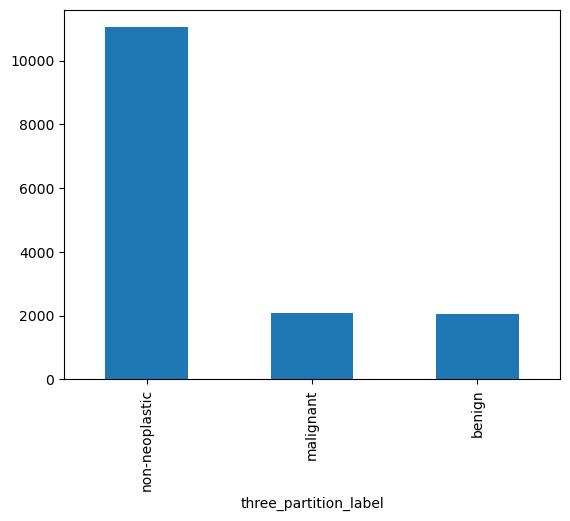

In [49]:
df["three_partition_label"].value_counts().plot(kind="bar")

To simplify the problem, we decided to study a binary classification Malignant/Benign. The non-neoplastic class will not be studied for now. 

We will only keep images from Malignant ans Benign classes. 

In [50]:
# Keep only benign + malignant

# 1) Filter to binary classes
df_binary = df[df["three_partition_label"].isin(["malignant", "benign"])].copy()
df_binary = df_binary.reset_index(drop=True)

# 2) Distribution (counts + percentages)
counts = df_binary["three_partition_label"].value_counts()
perc = df_binary["three_partition_label"].value_counts(normalize=True) * 100

print("Binary dataset size:", len(df_binary))
print("\nCounts:\n", counts)
print("\nPercentages (%):\n", perc.round(2))

Binary dataset size: 4125

Counts:
 three_partition_label
malignant    2081
benign       2044
Name: count, dtype: int64

Percentages (%):
 three_partition_label
malignant    50.45
benign       49.55
Name: proportion, dtype: float64


We observe that the classes are well balanced so there is no need to implement methods to balance the classes

In [51]:
IMG_SIZE = 256

val_transforms = A.Compose([
    # 1. Resize longest side to 256 (maintains aspect ratio)
    A.LongestMaxSize(max_size=IMG_SIZE),
    
    # 2. Pad remaining areas with zeros (black) to reach 256x256
    A.PadIfNeeded(
        min_height=IMG_SIZE, 
        min_width=IMG_SIZE, 
        border_mode=cv2.BORDER_CONSTANT, 
        value=0
    ),
    
    # 3. Normalize (ImageNet stats) & Convert to Tensor
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

C:\Users\kdiar\AppData\Local\Temp\ipykernel_9028\2589475980.py:8: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


In [52]:
class FitzpatrickBinaryDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
        # STRICT BINARY MAPPING
        self.label_map = {
            'benign': 0,
            'malignant': 1
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Get the path (ensure it is a string for cv2)
        img_path = str(self.df.iloc[idx]["path"])
        label_str = self.df.iloc[idx]["three_partition_label"]
        
        # 2. Load Image
        image = cv2.imread(img_path)
        
        if image is None:
            # Simple error handling: print and skip (or handle as needed)
            print(f"Warning: Could not load {img_path}")
            # Return a dummy tensor or handle index skipping (advanced)
            # For now, we'll assume data is clean since we filtered by df['downloaded']
            return torch.zeros((3, 256, 256)), torch.tensor(0)

        # 3. Convert BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 4. Apply Transforms (Pad & Resize)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # 5. Get Label
        label = torch.tensor(self.label_map[label_str], dtype=torch.long)

        return image, label

In [53]:
# Create the dataset
dataset = FitzpatrickBinaryDataset(dataframe=df_binary, transform=val_transforms)

# Create the loader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0) 
# Note: num_workers=0 is safer on Windows if you get multiprocessing errors

# Verify one batch
images, labels = next(iter(dataloader))
print(f"Images shape: {images.shape}")  # Should be [32, 3, 256, 256]
print(f"Labels: {labels}")              # Should be a mix of 0s and 1s



Images shape: torch.Size([32, 3, 256, 256])
Labels: tensor([0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
        0, 0, 0, 1, 0, 1, 1, 1])


In [54]:
# --- 1. STRATIFIED SPLIT ---
# First split: 80% Train, 20% Temp (Val + Test)
train_df, temp_df = train_test_split(
    df_binary, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_binary['three_partition_label'] # Crucial: Maintains the cancer ratio
)

# Second split: Divide Temp into 10% Validation and 10% Test
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['three_partition_label']
)

print(f"Data Split Sizes -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Data Split Sizes -> Train: 3300 | Val: 412 | Test: 413


In [55]:
# --- 2. TRANSFORMS ---
# Training: Needs data augmentation to prevent overfitting
train_transforms = A.Compose([
    A.LongestMaxSize(max_size=256),
    A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5), # Standard rotation for skin lesions
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation/Test: NO augmentation, just formatting
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=256),
    A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

C:\Users\kdiar\AppData\Local\Temp\ipykernel_9028\1262152957.py:5: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_CONSTANT, value=0),
C:\Users\kdiar\AppData\Local\Temp\ipykernel_9028\1262152957.py:16: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_CONSTANT, value=0),


In [56]:
# --- 3. CREATE DATASETS ---
# Using the FitzpatrickBinaryDataset class we defined earlier
train_dataset = FitzpatrickBinaryDataset(train_df, transform=train_transforms)
val_dataset = FitzpatrickBinaryDataset(val_df, transform=val_transforms)
test_dataset = FitzpatrickBinaryDataset(test_df, transform=val_transforms)

In [58]:
# --- 4. HANDLE IMBALANCE (WEIGHTED SAMPLER) ---
# We calculate weights ONLY on the training set to prevent data leakage
train_labels = [train_dataset.label_map[label] for label in train_df['three_partition_label']]
class_counts = np.bincount(train_labels)

# Formula: Weight = 1 / Frequency of the class
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_labels]

# Create the sampler
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [ ]:
# --- 5. CREATE DATALOADERS ---
BATCH_SIZE = 32

# Train loader uses the sampler (Note: shuffle MUST be False when using a sampler)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)

# Val and Test loaders are standard
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(" DataLoaders successfully created !")

✅ DataLoaders successfully created !


In [60]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=15, save_path='best_model.pth'):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = (torch.sigmoid(outputs) > 0.5).float()

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), save_path)
                print(f'  🌟 New best validation loss! Saved to {save_path}')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    model.load_state_dict(best_model_wts)
    return model, history

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()
EPOCHS = 15

# We need a separate DataLoader for the "No Augmentation" baseline
train_dataset_no_aug = FitzpatrickBinaryDataset(train_df, transform=val_transforms)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=32, sampler=sampler, num_workers=0)

# --- EXPERIMENT A: NO AUGMENTATION ---
print("🚀 STARTING EXPERIMENT A: NO AUGMENTATION")
model_no_aug = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model_no_aug.fc = nn.Linear(model_no_aug.fc.in_features, 1)
model_no_aug = model_no_aug.to(device)
optimizer_no_aug = torch.optim.Adam(model_no_aug.parameters(), lr=1e-4)

model_no_aug, history_no_aug = train_model(
    model_no_aug, train_loader_no_aug, val_loader, criterion, optimizer_no_aug, device, EPOCHS, 'model_baseline.pth'
)

# --- EXPERIMENT B: WITH AUGMENTATION ---
print("\n🚀 STARTING EXPERIMENT B: WITH AUGMENTATION")
model_aug = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model_aug.fc = nn.Linear(model_aug.fc.in_features, 1)
model_aug = model_aug.to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-4)

model_aug, history_aug = train_model(
    model_aug, train_loader, val_loader, criterion, optimizer_aug, device, EPOCHS, 'model_augmented.pth'
)

🚀 STARTING EXPERIMENT A: NO AUGMENTATION
Epoch 1/15
----------
Train Loss: 0.4919 | Acc: 0.7703
Val Loss: 0.4906 | Acc: 0.7985
  🌟 New best validation loss! Saved to model_baseline.pth

Epoch 2/15
----------
Train Loss: 0.2432 | Acc: 0.9039
Val Loss: 0.4062 | Acc: 0.8034
  🌟 New best validation loss! Saved to model_baseline.pth

Epoch 3/15
----------
Train Loss: 0.1451 | Acc: 0.9491
Val Loss: 0.4745 | Acc: 0.8155

Epoch 4/15
----------
Train Loss: 0.1044 | Acc: 0.9609
Val Loss: 0.4440 | Acc: 0.8107

Epoch 5/15
----------
Train Loss: 0.0736 | Acc: 0.9788
Val Loss: 0.5006 | Acc: 0.8083

Epoch 6/15
----------
Train Loss: 0.0397 | Acc: 0.9888
Val Loss: 0.5100 | Acc: 0.8180

Epoch 7/15
----------
Train Loss: 0.0463 | Acc: 0.9852
Val Loss: 0.6162 | Acc: 0.8155

Epoch 8/15
----------
Train Loss: 0.0326 | Acc: 0.9915
Val Loss: 0.5493 | Acc: 0.8131

Epoch 9/15
----------
Train Loss: 0.0514 | Acc: 0.9833
Val Loss: 0.5794 | Acc: 0.8301

Epoch 10/15
----------
Train Loss: 0.0235 | Acc: 0.9942
Val 

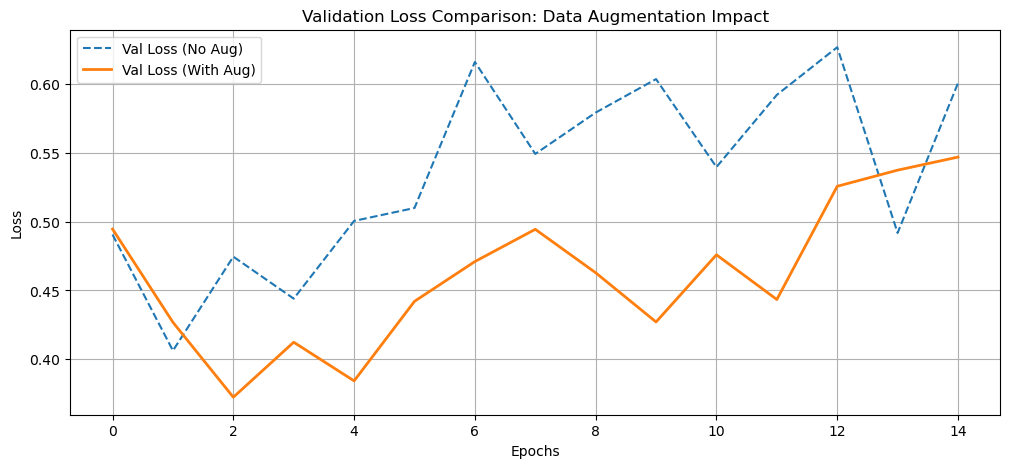

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(history_no_aug['val_loss'], label='Val Loss (No Aug)', linestyle='--')
plt.plot(history_aug['val_loss'], label='Val Loss (With Aug)', linewidth=2)
plt.title('Validation Loss Comparison: Data Augmentation Impact')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 1. Put the BASELINE model in evaluation mode
model_no_aug.eval()

all_preds_no_aug = []
all_probs_no_aug = []
all_labels_no_aug = []

print("Evaluating the Baseline Model (No Augmentation) on the Test Set...")

# 2. Run inference on Test Set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        # ---> USE model_no_aug HERE <---
        outputs = model_no_aug(inputs)
        probs = torch.sigmoid(outputs) # Get probabilities [0.0 to 1.0]
        preds = (probs > 0.5).float()  # Get binary class (0 or 1)
        
        all_probs_no_aug.extend(probs.cpu().numpy())
        all_preds_no_aug.extend(preds.cpu().numpy())
        all_labels_no_aug.extend(labels.cpu().numpy())

# Convert to 1D numpy arrays for Scikit-Learn
all_labels_no_aug = np.array(all_labels_no_aug).flatten()
all_preds_no_aug = np.array(all_preds_no_aug).flatten()
all_probs_no_aug = np.array(all_probs_no_aug).flatten()

# --- 3. METRICS COMPUTATION ---
print("\n--- Classification Report (No Augmentation) ---")
# 0 = Benign, 1 = Malignant
print(classification_report(all_labels_no_aug, all_preds_no_aug, target_names=['Benign', 'Malignant']))

# ROC-AUC Score (Global performance metric)
auc_no_aug = roc_auc_score(all_labels_no_aug, all_probs_no_aug)
print(f"ROC-AUC Score: {auc_no_aug:.4f} (1.0 is perfect, 0.5 is random guessing)")

# --- 4. CONFUSION MATRIX VISUALIZATION ---
cm_no_aug = confusion_matrix(all_labels_no_aug, all_preds_no_aug)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_no_aug, annot=True, fmt='d', cmap='Oranges', # Changed color to Oranges to easily distinguish from the other plot
            xticklabels=['Predicted Benign', 'Predicted Malignant'], 
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix: Baseline Model (No Aug)')
plt.show()

Evaluating the Augmented Model on the Test Set...

--- Classification Report ---
              precision    recall  f1-score   support

      Benign       0.79      0.87      0.83       205
   Malignant       0.86      0.77      0.81       208

    accuracy                           0.82       413
   macro avg       0.82      0.82      0.82       413
weighted avg       0.82      0.82      0.82       413

ROC-AUC Score: 0.9092 (1.0 is perfect, 0.5 is random guessing)


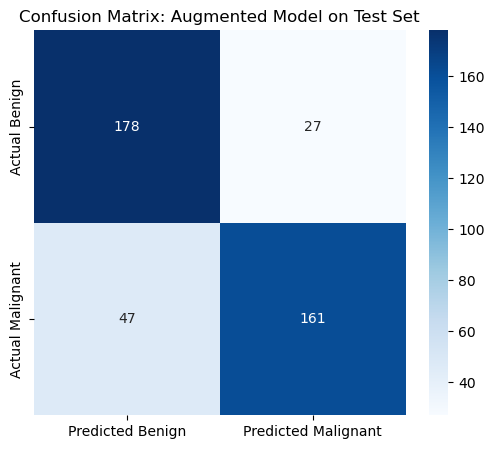

In [63]:
# 1. Put the AUGMENTED model in evaluation mode
model_aug.eval()

all_preds = []
all_probs = []
all_labels = []

print("Evaluating the Augmented Model on the Test Set...")

# 2. Run inference on Test Set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        # Make sure to use model_aug here!
        outputs = model_aug(inputs)
        probs = torch.sigmoid(outputs) # Get probabilities [0.0 to 1.0]
        preds = (probs > 0.5).float()  # Get binary class (0 or 1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to 1D numpy arrays for Scikit-Learn
all_labels = np.array(all_labels).flatten()
all_preds = np.array(all_preds).flatten()
all_probs = np.array(all_probs).flatten()

# --- 3. METRICS COMPUTATION ---
print("\n--- Classification Report ---")
# 0 = Benign, 1 = Malignant
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))

# ROC-AUC Score (Global performance metric)
auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {auc:.4f} (1.0 is perfect, 0.5 is random guessing)")

# --- 4. CONFUSION MATRIX VISUALIZATION ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Benign', 'Predicted Malignant'], 
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix: Augmented Model on Test Set')
plt.show()

In [64]:
def show_error(model, dataloader, device, num_images):
    """
    Parcourt le dataloader, trouve les prédictions erronées et affiche une grille.
    """
    model.eval()
    images_erronees = []
    vrais_labels = []
    labels_predits = []
    
    # Valeurs utilisées pour la normalisation ImageNet (à inverser)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    classes = ['Bénin', 'Malin']

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Prédictions
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze() # Ramène à 1D
            preds = (probs > 0.5).long()             # 0 ou 1
            
            # Trouver où le modèle s'est trompé
            # On s'assure que labels est bien en 1D pour la comparaison
            erreurs_mask = (preds != labels.squeeze()) 
            
            if erreurs_mask.any():
                # Extraire uniquement les tenseurs où il y a une erreur
                inputs_faux = inputs[erreurs_mask].cpu()
                preds_faux = preds[erreurs_mask].cpu()
                labels_faux = labels[erreurs_mask].cpu()
                
                for i in range(len(inputs_faux)):
                    if len(images_erronees) < num_images:
                        # Dé-normalisation pour l'affichage visuel
                        img = inputs_faux[i].numpy().transpose((1, 2, 0))
                        img = std * img + mean
                        img = np.clip(img, 0, 1) # S'assurer que les pixels sont entre 0 et 1
                        
                        images_erronees.append(img)
                        labels_predits.append(preds_faux[i].item())
                        vrais_labels.append(labels_faux[i].item())
                    else:
                        break
                        
            if len(images_erronees) >= num_images:
                break

    # --- Affichage avec Matplotlib ---
    if len(images_erronees) == 0:
        print("Incroyable, aucune erreur trouvée dans ce batch !")
        return

    fig, axes = plt.subplots(4, 3, figsize=(12, 8))
    fig.suptitle("Images Mal Classifiées par le Modèle", fontsize=16)
    
    for idx, ax in enumerate(axes.flatten()):
        if idx < len(images_erronees):
            ax.imshow(images_erronees[idx])
            vrai = classes[vrais_labels[idx]]
            predit = classes[labels_predits[idx]]
            
            # Titre en rouge pour souligner l'erreur
            ax.set_title(f"Vrai: {vrai} \nPrédit: {predit}", color="red", fontweight='bold')
            ax.axis('off')
        else:
            ax.axis('off') # Cacher les cases vides si on a moins de 6 erreurs
            
    plt.tight_layout()
    plt.show()

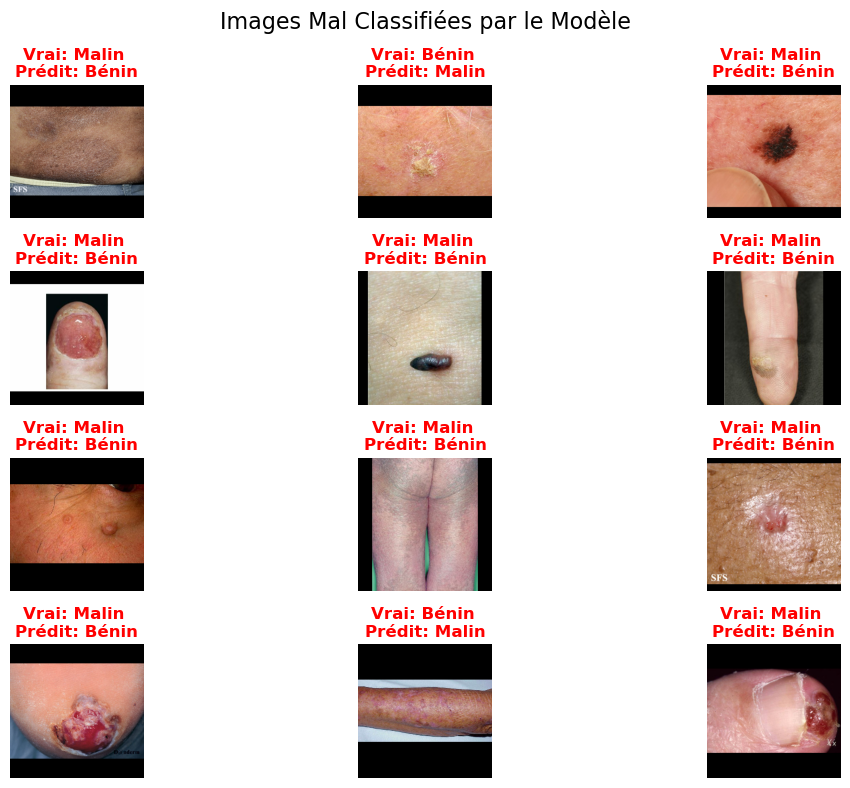

In [65]:
# Exemple of Errors 
show_error(model, test_loader, device, num_images=12)

In [ ]:
def evaluate_subgroup(model, dataloader, device, group_name):
    """Helper function to run inference and return metrics for a specific dataloader."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            
    # Calculate metrics
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Sensitivity (Recall for class 1: Malignant)
    sensitivity = recall_score(all_labels, all_preds)
    
    # Specificity (Recall for class 0: Benign)
    # Specificity is true negatives / (true negatives + false positives)
    specificity = recall_score(all_labels, all_preds, pos_label=0)
    
    # ROC-AUC
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0 # Occurs if a batch/subset only has one class
        
    print(f"--- {group_name} ---")
    print(f"Total Images: {len(all_labels)}")
    print(f"Sensitivity (Found Cancer): {sensitivity:.4f}")
    print(f"Specificity (Correct Benign): {specificity:.4f}")
    print(f"ROC-AUC: {auc:.4f}\n")
    
    return sensitivity, specificity, auc

# ==========================================
# 1. SLICE THE TEST DATAFRAME
# ==========================================
# Make sure your DataFrame has the 'fitzpatrick_scale' column.
# We filter out any missing/unknown values first.
valid_test_df = test_df[test_df['fitzpatrick_scale'].isin([1, 2, 3, 4, 5, 6])]

# Group 1: Light Skin (FST I, II, III)
light_skin_df = valid_test_df[valid_test_df['fitzpatrick_scale'].isin([1, 2, 3])]

# Group 2: Dark Skin (FST IV, V, VI)
dark_skin_df = valid_test_df[valid_test_df['fitzpatrick_scale'].isin([4, 5, 6])]

# ==========================================
# 2. CREATE DATALOADERS
# ==========================================
light_dataset = FitzpatrickBinaryDataset(light_skin_df, transform=val_transforms)
dark_dataset = FitzpatrickBinaryDataset(dark_skin_df, transform=val_transforms)

light_loader = DataLoader(light_dataset, batch_size=32, shuffle=False, num_workers=0)
dark_loader = DataLoader(dark_dataset, batch_size=32, shuffle=False, num_workers=0)

# ==========================================
# 3. RUN THE FAIRNESS AUDIT
# ==========================================
print(" RUNNING FAIRNESS AUDIT \n")
# Assuming 'model' and 'device' are already defined from Phase 3
light_sens, light_spec, light_auc = evaluate_subgroup(model, light_loader, device, "Light Skin (FST I-III)")
dark_sens, dark_spec, dark_auc = evaluate_subgroup(model, dark_loader, device, "Dark Skin (FST IV-VI)")

# Calculate Disparity
sens_diff = abs(light_sens - dark_sens)
print("--- Bias Summary ---")
print(f"Sensitivity Disparity: {sens_diff:.4f} (Ideal is 0.0)")
if sens_diff > 0.10:
    print("⚠️ WARNING: The model shows significant bias in detecting cancer between skin types!")
else:
    print("✅ The model shows acceptable fairness across skin types.")

🩺 RUNNING FAIRNESS AUDIT 🩺

--- Light Skin (FST I-III) ---
Total Images: 299
Sensitivity (Found Cancer): 0.6556
Specificity (Correct Benign): 0.8243
ROC-AUC: 0.8205

--- Dark Skin (FST IV-VI) ---
Total Images: 100
Sensitivity (Found Cancer): 0.5833
Specificity (Correct Benign): 0.9615
ROC-AUC: 0.8778

--- Bias Summary ---
Sensitivity Disparity: 0.0723 (Ideal is 0.0)
✅ The model shows acceptable fairness across skin types.


In [67]:
# --- 1. Filter the original dataframe for the excluded class ---
df_non_neo = df[df['three_partition_label'] == 'non-neoplastic'].copy()

# Keep only rows with valid Fitzpatrick scales for the fairness test
valid_non_neo = df_non_neo[df_non_neo['fitzpatrick_scale'].isin([1, 2, 3, 4, 5, 6])].copy()

# --->Take a random % sample <---
#valid_non_neo = valid_non_neo.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f"Testing on {len(valid_non_neo)} non-neoplastic images.")

# --- 2. Custom Dataset for Inference ---
class InferenceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = str(self.df.iloc[idx]["path"])
        image = cv2.imread(img_path)
        
        # Fallback for missing images
        if image is None:
            return torch.zeros((3, 256, 256)), -1 
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # Return the image AND the skin type scale (FST)
        fst = self.df.iloc[idx]["fitzpatrick_scale"]
        return image, fst

# --- 3. Create DataLoader ---
# We reuse the val_transforms from Phase 1
non_neo_dataset = InferenceDataset(valid_non_neo, transform=val_transforms)
non_neo_loader = DataLoader(non_neo_dataset, batch_size=32, shuffle=False, num_workers=0)

Testing on 10687 non-neoplastic images.


In [ ]:
# Put model in evaluation mode
model.eval()

all_preds = []
all_probs = []
all_fst = []

print("Running inference on non-neoplastic data...")

with torch.no_grad():
    for inputs, fst_scales in non_neo_loader:
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
        all_probs.extend(probs.cpu().numpy().flatten())
        all_preds.extend(preds.cpu().numpy().flatten())
        all_fst.extend(fst_scales.numpy().flatten())

# Combine results into a new DataFrame for easy analysis
results_df = pd.DataFrame({
    'Probability': all_probs,
    'Prediction': all_preds, # 0 = Benign, 1 = Malignant
    'FST': all_fst
})

# Filter out any broken images we caught in the Dataset class
results_df = results_df[results_df['FST'] != -1]

# ==========================================
# FAIRNESS ANALYSIS
# ==========================================

def analyze_group(df_group, group_name):
    total = len(df_group)
    if total == 0: return
    
    # How many were predicted as Malignant? (These are False Positives)
    predicted_malignant = df_group['Prediction'].sum()
    malignant_rate = (predicted_malignant / total) * 100
    
    print(f"--- {group_name} ---")
    print(f"Total Images: {total}")
    print(f"Predicted Benign (Correct behavior): {total - predicted_malignant} ({(100 - malignant_rate):.1f}%)")
    print(f"Predicted Malignant (False Alarm!): {predicted_malignant} ({malignant_rate:.1f}%)")
    print(f"Average Confidence Score: {df_group['Probability'].mean():.4f}\n")
    
    return malignant_rate

print("\n OUT-OF-DISTRIBUTION & FAIRNESS REPORT \n")

# 1. Overall Performance
overall_rate = analyze_group(results_df, "All Non-Neoplastic Images")

# 2. Light Skin (FST 1, 2, 3)
light_skin_df = results_df[results_df['FST'].isin([1, 2, 3])]
light_rate = analyze_group(light_skin_df, "Light Skin (FST I-III)")

# 3. Dark Skin (FST 4, 5, 6)
dark_skin_df = results_df[results_df['FST'].isin([4, 5, 6])]
dark_rate = analyze_group(dark_skin_df, "Dark Skin (FST IV-VI)")

# 4. Disparity Check
if light_rate is not None and dark_rate is not None:
    disparity = abs(light_rate - dark_rate)
    print("--- Bias Summary ---")
    print(f"False Alarm Disparity: {disparity:.1f}%")
    if disparity > 10.0:
        print(" WARNING: The model has a severe bias. It is much more likely to trigger a false alarm on one skin type over the other.")
    else:
        print(" The model treats non-neoplastic lesions relatively equally across skin types.")

Running inference on non-neoplastic data...

🩺 OUT-OF-DISTRIBUTION & FAIRNESS REPORT 🩺

--- All Non-Neoplastic Images ---
Total Images: 10687
Predicted Benign (Correct behavior): 8109.0 (75.9%)
Predicted Malignant (False Alarm!): 2578.0 (24.1%)
Average Confidence Score: 0.3014

--- Light Skin (FST I-III) ---
Total Images: 7078
Predicted Benign (Correct behavior): 5223.0 (73.8%)
Predicted Malignant (False Alarm!): 1855.0 (26.2%)
Average Confidence Score: 0.3175

--- Dark Skin (FST IV-VI) ---
Total Images: 3609
Predicted Benign (Correct behavior): 2886.0 (80.0%)
Predicted Malignant (False Alarm!): 723.0 (20.0%)
Average Confidence Score: 0.2698

--- Bias Summary ---
False Alarm Disparity: 6.2%
✅ The model treats non-neoplastic lesions relatively equally across skin types.
